<a href="https://colab.research.google.com/github/alexandrumoldovan1/housing-prices-ml/blob/main/01_data_loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Notebook 1 — Data Loading
## Predictive Modelling of Housing Prices Using Machine Learning
### NYC Rolling Sales Data | Feb 2025 – Jan 2026

In [2]:
# Install libraries
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load all 5 boroughs directly from GitHub
base = "https://raw.githubusercontent.com/alexandrumoldovan1/housing-prices-ml/main/data/"

files = {
    'Manhattan':     base + 'rollingsales_manhattan.xlsx',
    'Brooklyn':      base + 'rollingsales_brooklyn.xlsx',
    'Queens':        base + 'rollingsales_queens.xlsx',
    'Bronx':         base + 'rollingsales_bronx.xlsx',
    'Staten Island': base + 'rollingsales_statenisland.xlsx'
}

dfs = []
for borough, url in files.items():
    temp = pd.read_excel(url, skiprows=4)
    temp['BOROUGH_NAME'] = borough
    dfs.append(temp)
    print(f"{borough}: {len(temp):,} records loaded")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal dataset: {len(df):,} rows x {df.shape[1]} columns")

Manhattan: 19,251 records loaded
Brooklyn: 22,399 records loaded
Queens: 26,385 records loaded
Bronx: 6,498 records loaded
Staten Island: 7,036 records loaded

Total dataset: 81,569 rows x 22 columns


In [4]:
# First look at the data
df.head(10)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASEMENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,BOROUGH_NAME
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,372,9,NaN,C7,272 EAST 3 STREET,NaN,...,1.0,9.0,2021.0,7129.0,1900.0,2,C7,0,2025-12-15,Manhattan
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,372,19,NaN,C7,"292 EAST 3 STREET, 4B",NaN,...,1.0,10.0,2401.0,6920.0,1920.0,2,C7,0,2025-02-07,Manhattan
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,41,NaN,C6,"745 EAST 6TH STREET, 1B",NaN,...,0.0,28.0,4542.0,18254.0,1900.0,2,C4,540000,2025-12-17,Manhattan
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,385,38,NaN,C6,"21-23 AVENUE C, 5B",NaN,...,2.0,22.0,3315.0,17160.0,1900.0,2,C4,0,2025-11-11,Manhattan
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,396,26,NaN,C4,638 EAST 14 STREET,NaN,...,0.0,20.0,2779.0,10740.0,1920.0,2,C4,0,2025-05-01,Manhattan
5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,396,27,NaN,C4,640 EAST 14 STREET,NaN,...,0.0,20.0,2831.0,10900.0,1920.0,2,C4,0,2025-05-01,Manhattan
6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,400,11,NaN,C4,"510 EAST 5TH STREET, 9",NaN,...,0.0,18.0,2404.0,6875.0,1900.0,2,C4,280000,2025-04-29,Manhattan
7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,400,54,NaN,C7,207 EAST 4 STREET,NaN,...,3.0,11.0,2364.0,7166.0,1900.0,2,C7,8800000,2025-11-20,Manhattan
8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,36,NaN,C4,106 AVENUE B,NaN,...,2.0,10.0,1919.0,7810.0,1900.0,2,C4,2000000,2025-03-13,Manhattan
9,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,404,14,NaN,C7,520 EAST 11TH STREET,NaN,...,3.0,30.0,3553.0,13476.0,1900.0,2,C7,0,2025-09-19,Manhattan


In [5]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                   Missing Count  Missing %
EASEMENT                   81569      100.0
APARTMENT NUMBER           61540       75.4
LAND SQUARE FEET           37349       45.8
GROSS SQUARE FEET          37347       45.8
COMMERCIAL UNITS           34189       41.9
RESIDENTIAL UNITS          20342       24.9
TOTAL UNITS                17182       21.1
YEAR BUILT                  5328        6.5
ZIP CODE                      17        0.0


In [6]:
# Basic statistics for numeric columns
df.describe()

,BOROUGH,BLOCK,LOT,EASEMENT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
count,81569.000000,81569.000000,81569.000000,0.0,81552.000000,61227.000000,47380.000000,64387.000000,4.422000e+04,4.422200e+04,76241.000000,81569.000000,8.156900e+04,81569
mean,2.944305,4187.870760,392.439787,NaN,10847.730221,2.656638,0.377986,2.804402,5.811226e+03,5.107588e+03,1952.537139,1.662715,2.151114e+06,2025-08-10 02:34:12.338511104
min,1.000000,1.000000,1.000000,NaN,10001.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,35.000000,1.000000,0.000000e+00,2025-02-01 00:00:00
25%,2.000000,1274.000000,22.000000,NaN,10304.000000,1.000000,0.000000,1.000000,2.000000e+03,1.396000e+03,1925.000000,1.000000,0.000000e+00,2025-05-15 00:00:00
50%,3.000000,3252.000000,51.000000,NaN,11209.000000,1.000000,0.000000,1.000000,2.500000e+03,1.998000e+03,1950.000000,2.000000,5.190000e+05,2025-08-08 00:00:00
75%,4.000000,6185.000000,1003.000000,NaN,11357.000000,2.000000,0.000000,2.000000,4.000000e+03,2.826750e+03,1974.000000,2.000000,1.100000e+06,2025-11-04 00:00:00
max,5.000000,16350.000000,9049.000000,NaN,11697.000000,761.000000,472.000000,764.000000,7.446955e+06,1.545708e+06,2025.000000,4.000000,1.080000e+09,2026-02-28 00:00:00
std,1.299661,3563.115189,657.227327,NaN,569.971455,16.078123,5.647514,16.461226,1.037615e+05,3.465167e+04,37.054575,0.810786,1.524212e+07,NaN


Records per borough:
BOROUGH_NAME
Queens           26385
Brooklyn         22399
Manhattan        19251
Staten Island     7036
Bronx             6498
Name: count, dtype: int64


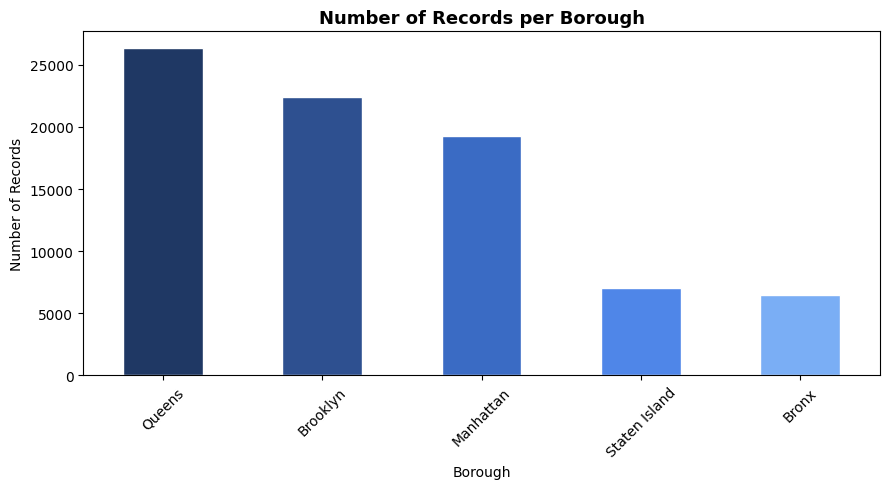

In [7]:
# Records per borough
borough_counts = df['BOROUGH_NAME'].value_counts()
print("Records per borough:")
print(borough_counts)

# Bar chart
plt.figure(figsize=(9, 5))
colors = ['#1F3864','#2E5090','#3A6BC4','#4F86E8','#7AAEF5']
borough_counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Number of Records per Borough', fontsize=13, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Sale price distribution
print("SALE PRICE Overview:")
print(f"  Total records:        {len(df):,}")
print(f"  Price = $0:           {(df['SALE PRICE'] == 0).sum():,} ({(df['SALE PRICE'] == 0).mean()*100:.1f}%)")
print(f"  Price > $0:           {(df['SALE PRICE'] > 0).sum():,}")
print(f"  Price > $10,000:      {(df['SALE PRICE'] > 10000).sum():,}")
print(f"  Max price:            ${df['SALE PRICE'].max():,}")
print(f"  Median price:         ${df['SALE PRICE'].median():,.0f}")

SALE PRICE Overview:
  Total records:        81,569
  Price = $0:           27,641 (33.9%)
  Price > $0:           53,928
  Price > $10,000:      52,238
  Max price:            $1,080,000,000
  Median price:         $519,000


In [10]:
df.to_csv('combined_raw.csv', index=False)